In [22]:
import numpy as np
import lib_debug

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


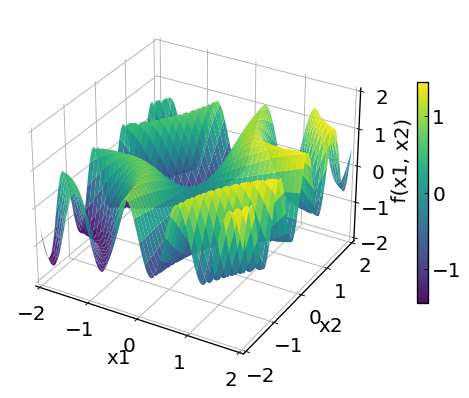

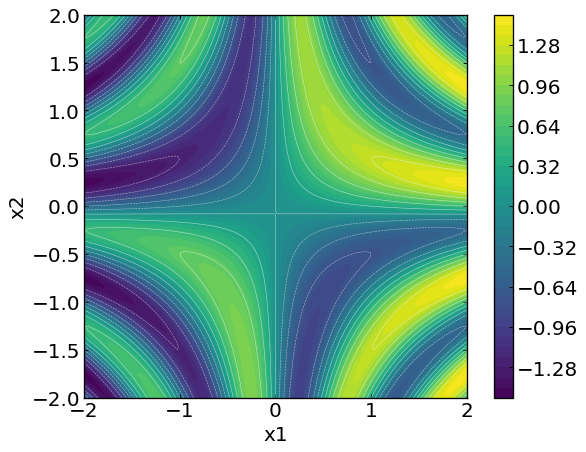

--- Strategy Selected: LCB (2D, SyntheticFunc2) ---
--- Starting Optimization Loop (25 iterations) ---
Iter  | Best y     | New y      | New x
--------------------------------------------------------------------------------
1     | -1.442633   | -0.270251   | [-1.483, -2.000]
2     | -1.442633   | -0.496617   | [-2.000, -2.000]
3     | -1.442633   | -0.944080   | [-0.516,  1.358]
4     | -1.442633   | -0.127389   | [-0.558,  1.802]
5     | -1.442633   | -0.856784   | [-0.286,  1.026]
6     | -1.442633   | -1.137919   | [-0.710,  0.848]
7     | -1.442633   | -0.800789   | [-0.497,  0.483]
8     | -1.442633   | -1.203109   | [-0.938,  0.463]
9     | -1.442633   | -1.024208   | [-1.352,  0.176]
10    | -1.442633   | -0.084227   | [-1.793, -0.063]
11    | -1.442633   | -0.538186   | [ 0.146, -1.370]
12    | -1.442633   | 0.388759   | [-0.068, -1.972]
13    | -1.442633   | -0.491638   | [-2.000,  2.000]
14    | -1.442633   | -0.775741   | [-1.430,  2.000]
15    | -1.442633   | -1.220804   |

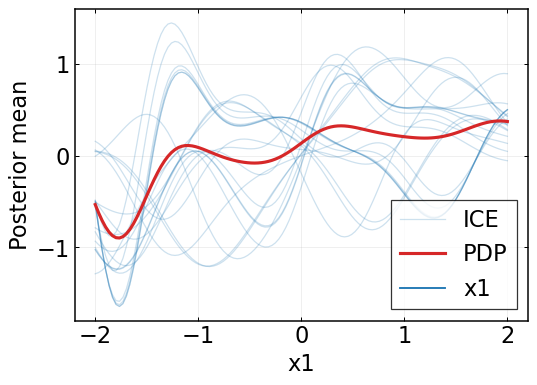

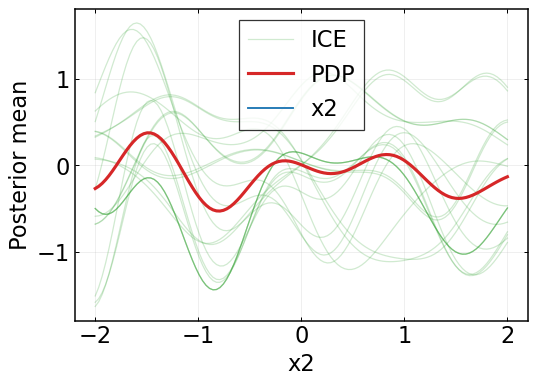

In [41]:

# -------------------- 1. Setup & Aliasing --------------------
kernel = lib_debug.rbf_kernel

# -------------------- 2. Settings --------------------
# Hyperparameters
gamma = 4.0
noise_std = 0.01
noise_var = noise_std ** 2

# Domain settings (2D)
dims = 2
lower_bounds = [-2.0, -2.0]
upper_bounds = [2.0, 2.0]

# -------------------- 2.5 Synthetic Functions (ICE/PDP study) --------------------
def SyntheticFunc1(X):
    """ICE/PDPが有効な例（独立・加法的）。"""
    X = np.atleast_2d(X)
    x1 = X[:, 0]
    x2 = X[:, 1]
    return 1.5 * np.sin(np.pi * x1) + 0.25 * x1**2 + 0.8 * np.cos(np.pi * x2)


def SyntheticFunc2(X):
    """ICE/PDPが有効でない例1（強い交互作用）。"""
    X = np.atleast_2d(X)
    x1 = X[:, 0]
    x2 = X[:, 1]
    return np.sin(np.pi * x1 * x2) + 0.25 * x1


def SyntheticFunc3(X):
    """ICE/PDPが有効でない例2（相関入力を前提）。"""
    X = np.atleast_2d(X)
    x1 = X[:, 0]
    x2 = X[:, 1]
    return np.exp(-5.0 * (x1 - x2) ** 2) + 0.2 * np.sin(2.0 * np.pi * (x1 + x2))


def sample_inputs(func_name, n, rng=None):
    """関数ごとの入力分布に従って2次元入力をサンプリング。"""
    rng = np.random.default_rng() if rng is None else rng
    if func_name in ("SyntheticFunc1", "SyntheticFunc2"):
        # x1, x2 iid ~ Unif[-2, 2]
        return rng.uniform(-2.0, 2.0, size=(n, 2))
    if func_name == "SyntheticFunc3":
        # x1 ~ Unif[-2,2], eta ~ N(0, 0.1^2), x2 = x1 + eta
        x1 = rng.uniform(-2.0, 2.0, size=n)
        eta = rng.normal(0.0, 0.1, size=n)
        x2 = x1 + eta
        return np.column_stack([x1, x2])
    raise ValueError(f"Unknown function name: {func_name}")


# 使用する関数を選択（"SyntheticFunc1" / "SyntheticFunc2" / "SyntheticFunc3"）
target_func_name = "SyntheticFunc1"
target_func = {"SyntheticFunc1": SyntheticFunc1, "SyntheticFunc2": SyntheticFunc2, "SyntheticFunc3": SyntheticFunc3}[target_func_name]



# -------------------- 2.6 Selected function visualization (x1-x2) --------------------
plot_grid_n = 120
x1_plot = np.linspace(lower_bounds[0], upper_bounds[0], plot_grid_n)
x2_plot = np.linspace(lower_bounds[1], upper_bounds[1], plot_grid_n)
X1_plot, X2_plot = np.meshgrid(x1_plot, x2_plot)
X_plot = np.column_stack([X1_plot.ravel(), X2_plot.ravel()])
Y_plot = target_func(X_plot).reshape(X1_plot.shape)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(13, 5), dpi=100)
ax3d = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax3d.plot_surface(X1_plot, X2_plot, Y_plot, cmap='viridis', linewidth=0, antialiased=True, alpha=0.95)
ax3d.set_title(f'{target_func_name}: 3D surface')
ax3d.set_xlabel('x1')
ax3d.set_ylabel('x2')
ax3d.set_zlabel('f(x1, x2)')
fig.colorbar(surf, ax=ax3d, shrink=0.6, pad=0.08)

ax2d = fig.add_subplot(1, 2, 2)
cont = ax2d.contourf(X1_plot, X2_plot, Y_plot, levels=40, cmap='viridis')
ax2d.contour(X1_plot, X2_plot, Y_plot, levels=12, colors='white', linewidths=0.5, alpha=0.6)
ax2d.set_title(f'{target_func_name}: 2D projection')
ax2d.set_xlabel('x1')
ax2d.set_ylabel('x2')
ax2d.set_aspect('equal', adjustable='box')
fig.colorbar(cont, ax=ax2d)

plt.tight_layout()
plt.show()

# -------------------- 2.7 Cross-sections at x1=0 / x2=0 --------------------
cross_grid_n = 400
x1_cross = np.linspace(lower_bounds[0], upper_bounds[0], cross_grid_n)
x2_cross = np.linspace(lower_bounds[1], upper_bounds[1], cross_grid_n)

y_x2eq0 = target_func(np.column_stack([x1_cross, np.zeros_like(x1_cross)]))
y_x1eq0 = target_func(np.column_stack([np.zeros_like(x2_cross), x2_cross]))

fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=100)
ax.plot(x1_cross, y_x2eq0, color='tab:blue', linewidth=2.0)
ax.set_title(f'{target_func_name}: cross-section (x2=0)')
ax.set_xlabel('x1')
ax.set_ylabel('f(x1, x2=0)')
ax.grid(alpha=0.25)

fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=100)
ax.plot(x2_cross, y_x1eq0, color='tab:orange', linewidth=2.0)
ax.set_title(f'{target_func_name}: cross-section (x1=0)')
ax.set_xlabel('x2')
ax.set_ylabel('f(x1=0, x2)')
ax.grid(alpha=0.25)

plt.show()

# Optimization Loop Settings
n_init = 20
n_iter = 25

# --- Acquisition Function (LCB only) ---
acq_func = lib_debug.lower_confidence_bound
acq_params = {"kappa": 2.0}

print(f"--- Strategy Selected: LCB (2D, {target_func_name}) ---")

# -------------------- 3. Initialization --------------------
X_train = sample_inputs(target_func_name, n_init, rng=np.random.default_rng(0))
y_train = target_func(X_train).reshape(-1, 1) + np.random.normal(0, noise_std, (len(X_train), 1))

# Keep copy for plotting/analysis
X_init_plot = X_train.copy()
y_init_plot = y_train.copy()

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'New x'}")
print("-" * 80)

for i in range(n_iter):
    Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)

    x_new, _ = lib_debug.optimize_acquisition(
        kernel,
        acq_func,
        X_train,
        y_train,
        Ky_inv,
        gamma,
        lower_bounds,
        upper_bounds,
        acq_params,
    )

    y_new = target_func(x_new.reshape(1, -1)).reshape(1, 1) + np.random.normal(0, noise_std, (1, 1))

    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])

    current_best = np.min(y_train)
    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | [{x_new[0]: .3f}, {x_new[1]: .3f}]")

# -------------------- 5. Final fit --------------------
Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)
best_idx_final = np.argmin(y_train)
best_x = X_train[best_idx_final]
best_y = y_train[best_idx_final]

print("-" * 80)
print(f"Optimization Finished using LCB on 2D {target_func_name}.")
print(f"Global Best Found: y = {best_y.item():.6f} at x = [{best_x[0]:.4f}, {best_x[1]:.4f}]")

# -------------------- 6. Correct ICE & PDP from final posterior (2D) --------------------
# Definitions used here:
# ICE_j^i(z): prediction for sample i while varying feature j to z and fixing other features.
# PDP_j(z): mean_i ICE_j^i(z)

# Grid for each feature
n_pdp_grid = 120
x1_grid = np.linspace(lower_bounds[0], upper_bounds[0], n_pdp_grid)
x2_grid = np.linspace(lower_bounds[1], upper_bounds[1], n_pdp_grid)

# Keep a manageable subset for visible ICE curves
rng = np.random.default_rng(42)
n_ice = min(20, len(X_train))
ice_idx = rng.choice(len(X_train), size=n_ice, replace=False)
X_anchor = X_train[ice_idx]

# Helper: GP posterior mean for batched points
mu_cache = {}
def gp_mu(x):
    key = tuple(np.round(x, 10))
    if key not in mu_cache:
        mu_cache[key] = lib_debug.get_posterior(kernel, np.array(x), X_train, y_train, Ky_inv, gamma)[0]
    return mu_cache[key]

# Feature-1 ICE/PDP (vary x1, fix x2 from anchors)
ice_f1 = []
for anchor in X_anchor:
    curve = []
    for z in x1_grid:
        x = [z, anchor[1]]
        curve.append(gp_mu(x))
    ice_f1.append(np.array(curve))
ice_f1 = np.array(ice_f1)
pdp_f1 = ice_f1.mean(axis=0)

# Feature-2 ICE/PDP (vary x2, fix x1 from anchors)
ice_f2 = []
for anchor in X_anchor:
    curve = []
    for z in x2_grid:
        x = [anchor[0], z]
        curve.append(gp_mu(x))
    ice_f2.append(np.array(curve))
ice_f2 = np.array(ice_f2)
pdp_f2 = ice_f2.mean(axis=0)

# -------------------- 7. Plot ICE/PDP --------------------
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=90)

for i, curve in enumerate(ice_f1):
    ax.plot(
        x1_grid,
        curve,
        color='tab:blue',
        alpha=0.22,
        linewidth=1.0,
        label='ICE' if i == 0 else None
    )

ax.plot(
    x1_grid,
    pdp_f1,
    color='tab:red',
    linewidth=2.5,
    label='PDP'
)

ax.plot([], [], label='x1', ls=None)
ax.set_xlabel('x1')
ax.set_ylabel('Posterior mean')
ax.grid(alpha=0.2)
ax.legend()

fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=90)

for i, curve in enumerate(ice_f2):
    ax.plot(
        x2_grid,
        curve,
        color='tab:green',
        alpha=0.22,
        linewidth=1.0,
        label='ICE' if i == 0 else None
    )

ax.plot(
    x2_grid,
    pdp_f2,
    color='tab:red',
    linewidth=2.5,
    label='PDP'
)

ax.plot([], [], label='x2', ls=None)
ax.set_xlabel('x2')
ax.set_ylabel('Posterior mean')
ax.grid(alpha=0.2)
ax.legend()

plt.show()
